# Задание № 1:
1. Загрузить последовательность отсчетов из файла «lab_3_z1.bin».
Формат записи данных в файле — бинарный, integer16 (int16, 2 байта на отсчет); частота
дискретизации 1 кГц.
2. Изобразить загруженную последовательность на графике.
3. Выполнить текущее усреднение (moving average или running mean) последовательности по
окну с эквивалентной длительностью 10 секунд.
4. Изобразить результат усреднения на графике на графике.

Дополнительное задание [+2 балла]: 
*произвести детрендирование данных.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [22]:
files_noise = [
    '.\\data\\rwm-2024-12-04\\noise20241204T090020.bin',
    '.\\data\\rwm-2024-12-04\\noise20241204T093021.bin',
    '.\\data\\rwm-2024-12-04\\noise20241204T100020.bin',
    '.\\data\\rwm-2024-12-04\\noise20241204T103021.bin',
    '.\\data\\rwm-2024-12-04\\noise20241204T110021.bin'
]

files_rwm = [
    '.\\data\\rwm-2024-12-04\\rwm20241204T090020.bin',
    '.\\data\\rwm-2024-12-04\\rwm20241204T093021.bin',
    '.\\data\\rwm-2024-12-04\\rwm20241204T100020.bin',
    '.\\data\\rwm-2024-12-04\\rwm20241204T103021.bin',
    '.\\data\\rwm-2024-12-04\\rwm20241204T110021.bin'
]

file: .\data\rwm-2024-12-04\rwm20241204T090020.bin
len: 479232
file: .\data\rwm-2024-12-04\rwm20241204T093021.bin
len: 479232
file: .\data\rwm-2024-12-04\rwm20241204T100020.bin
len: 479232
file: .\data\rwm-2024-12-04\rwm20241204T103021.bin
len: 479232
file: .\data\rwm-2024-12-04\rwm20241204T110021.bin
len: 479232
file: .\data\rwm-2024-12-04\noise20241204T090020.bin
len: 239616
file: .\data\rwm-2024-12-04\noise20241204T093021.bin
len: 239616
file: .\data\rwm-2024-12-04\noise20241204T100020.bin
len: 239616
file: .\data\rwm-2024-12-04\noise20241204T103021.bin
len: 239616
file: .\data\rwm-2024-12-04\noise20241204T110021.bin
len: 239616


c:\Users\Gordey\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Gordey\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


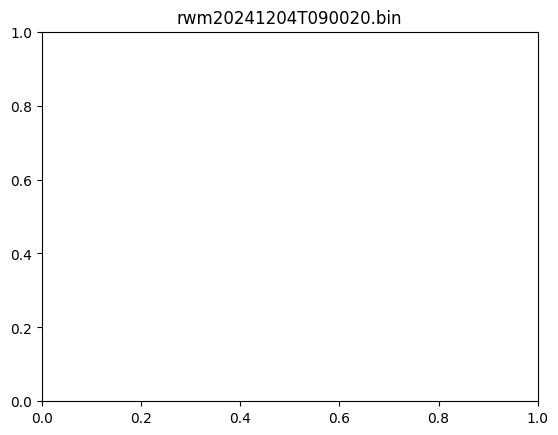

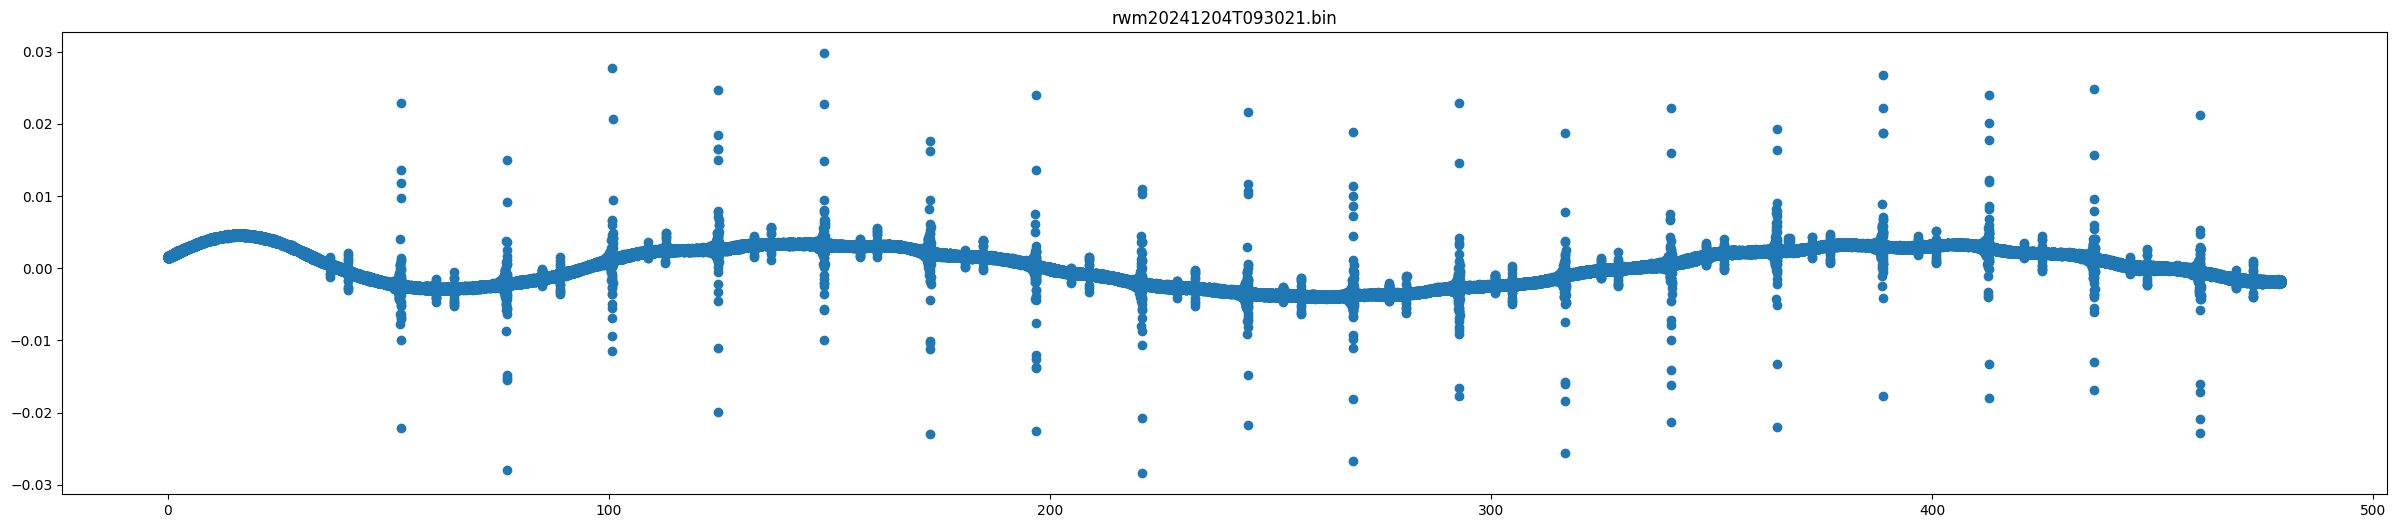

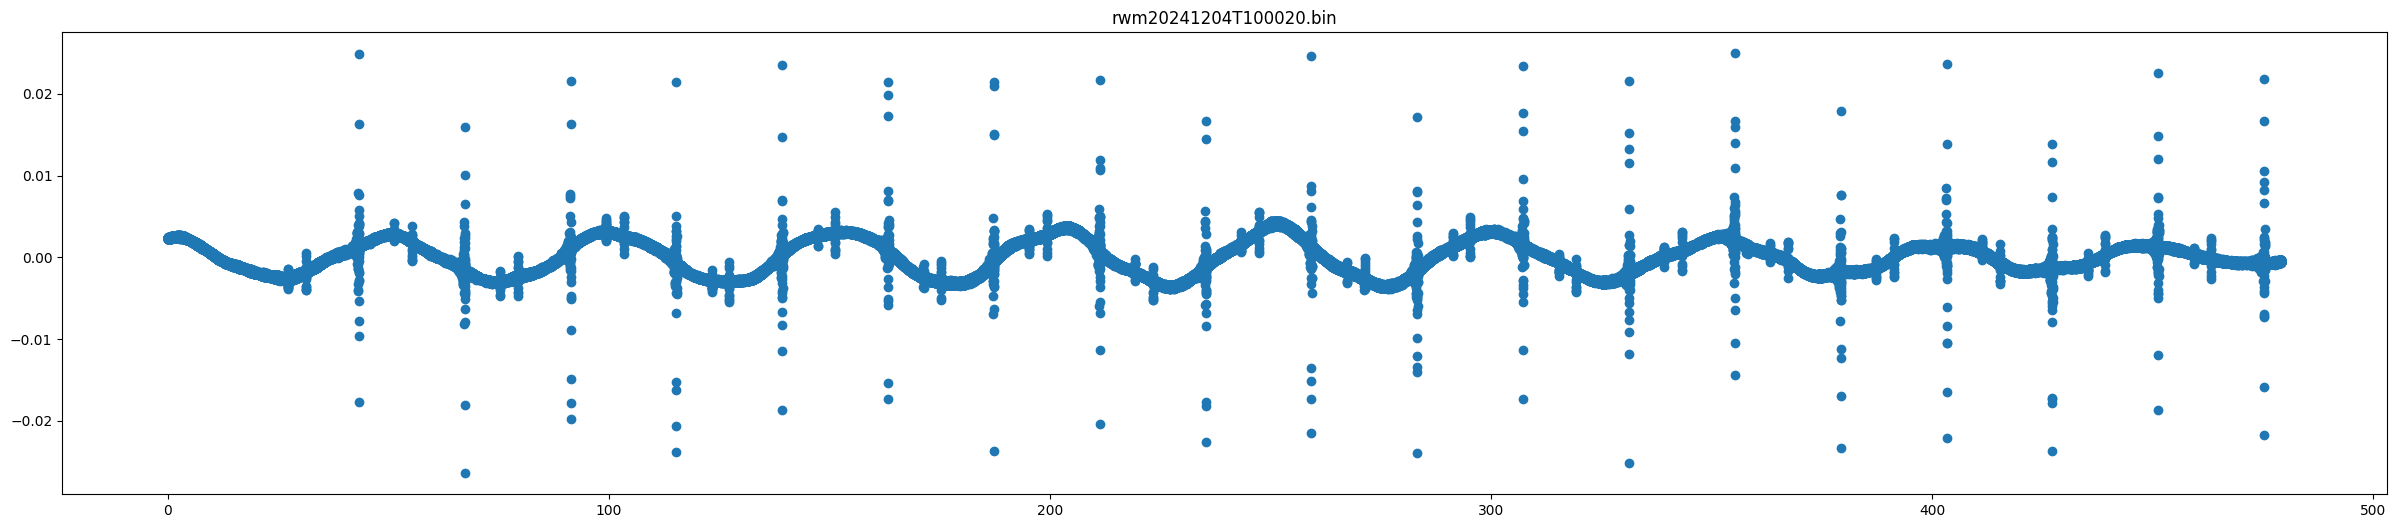

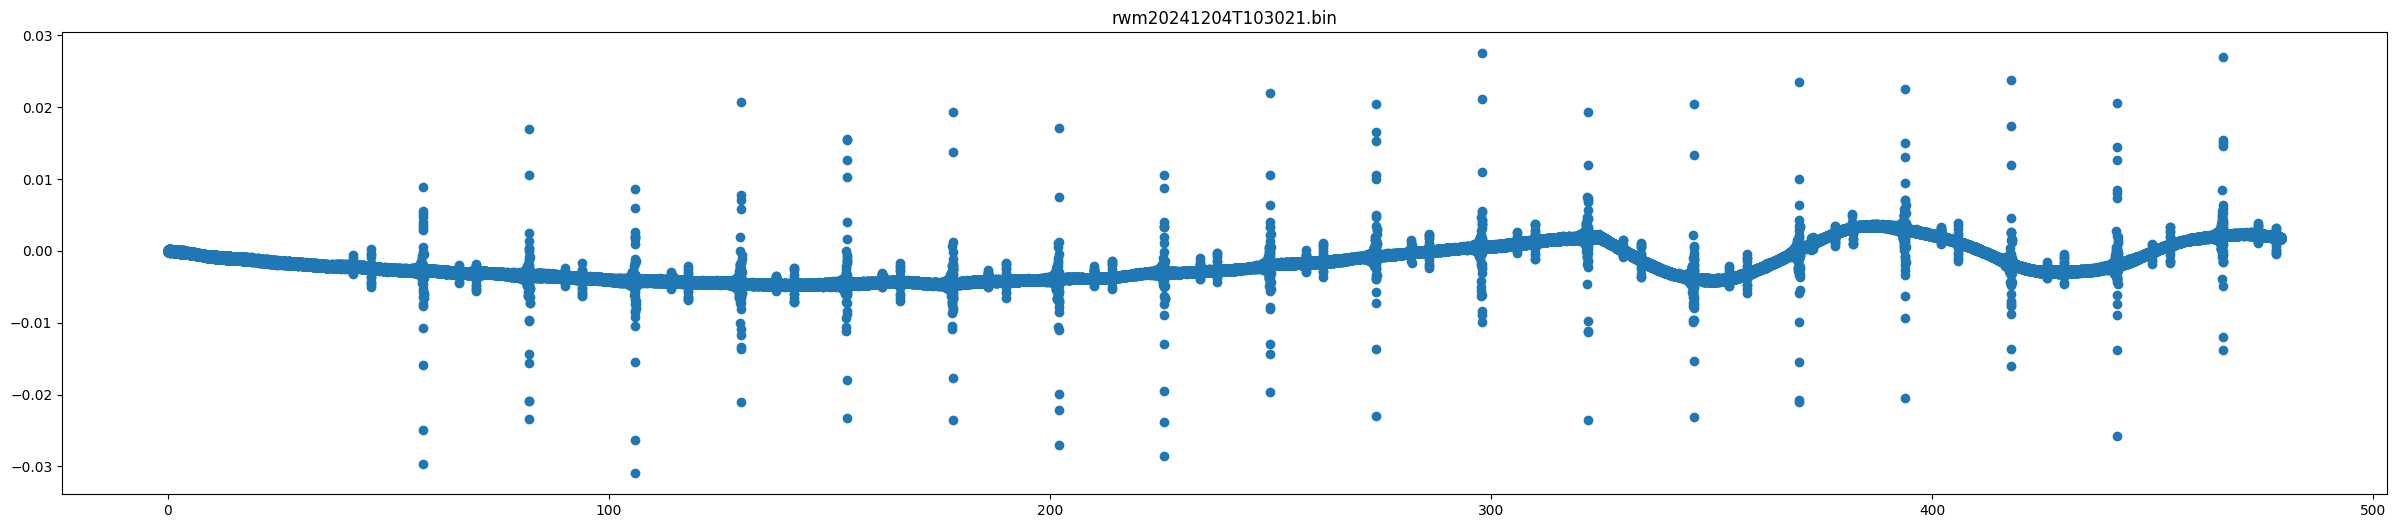

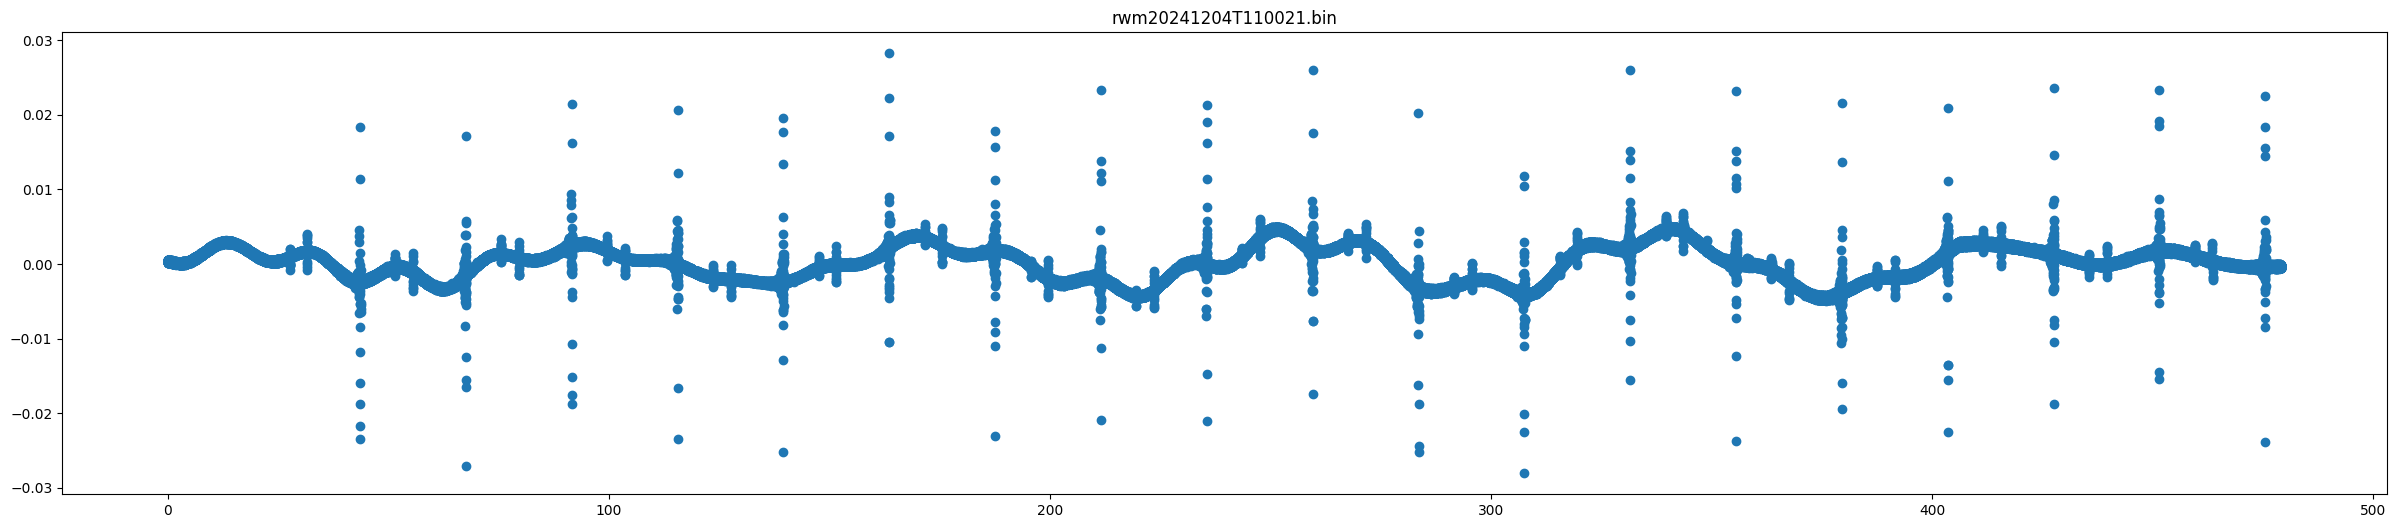

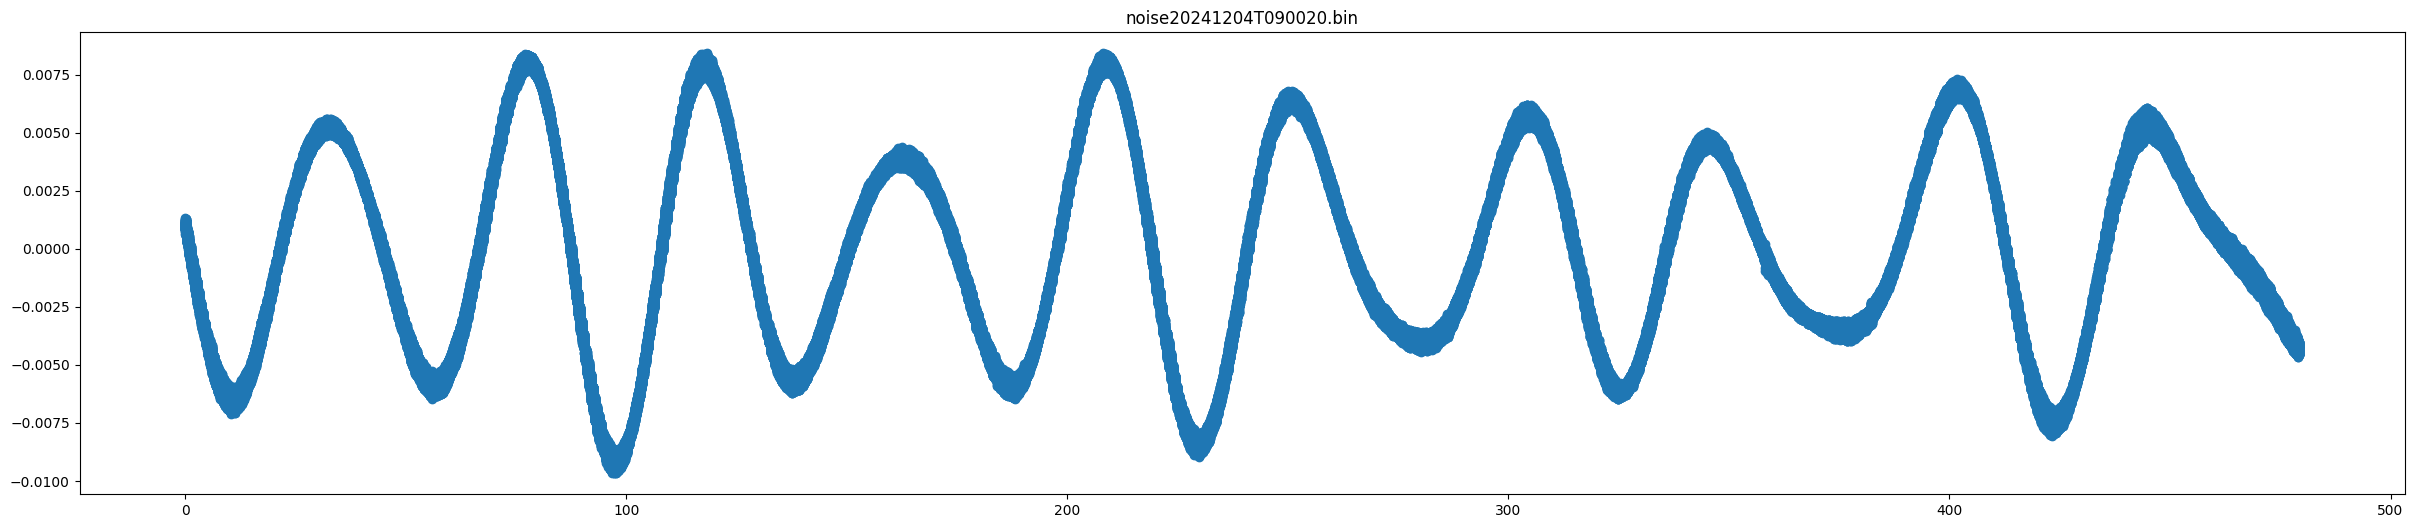

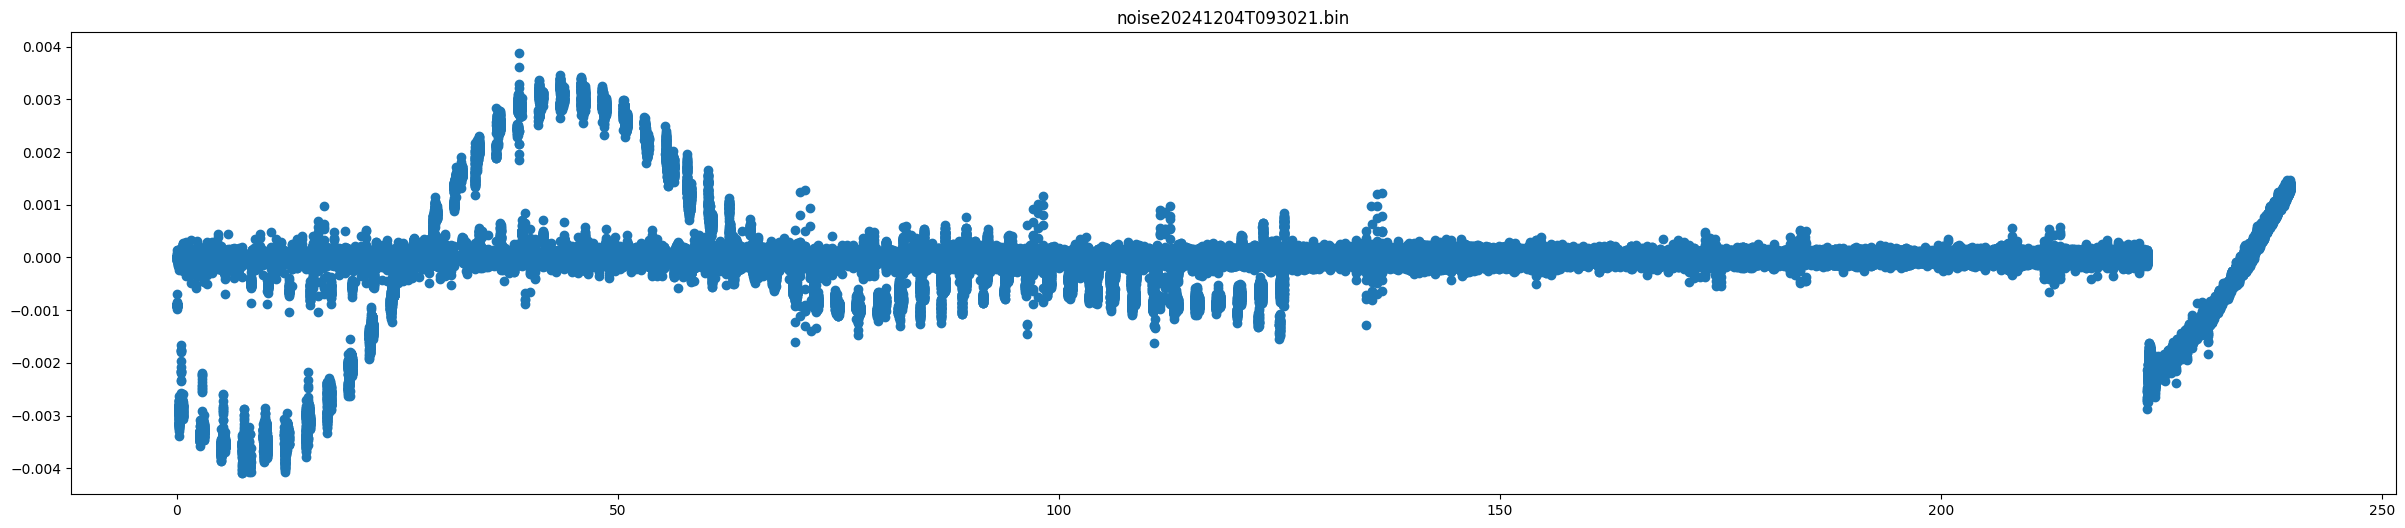

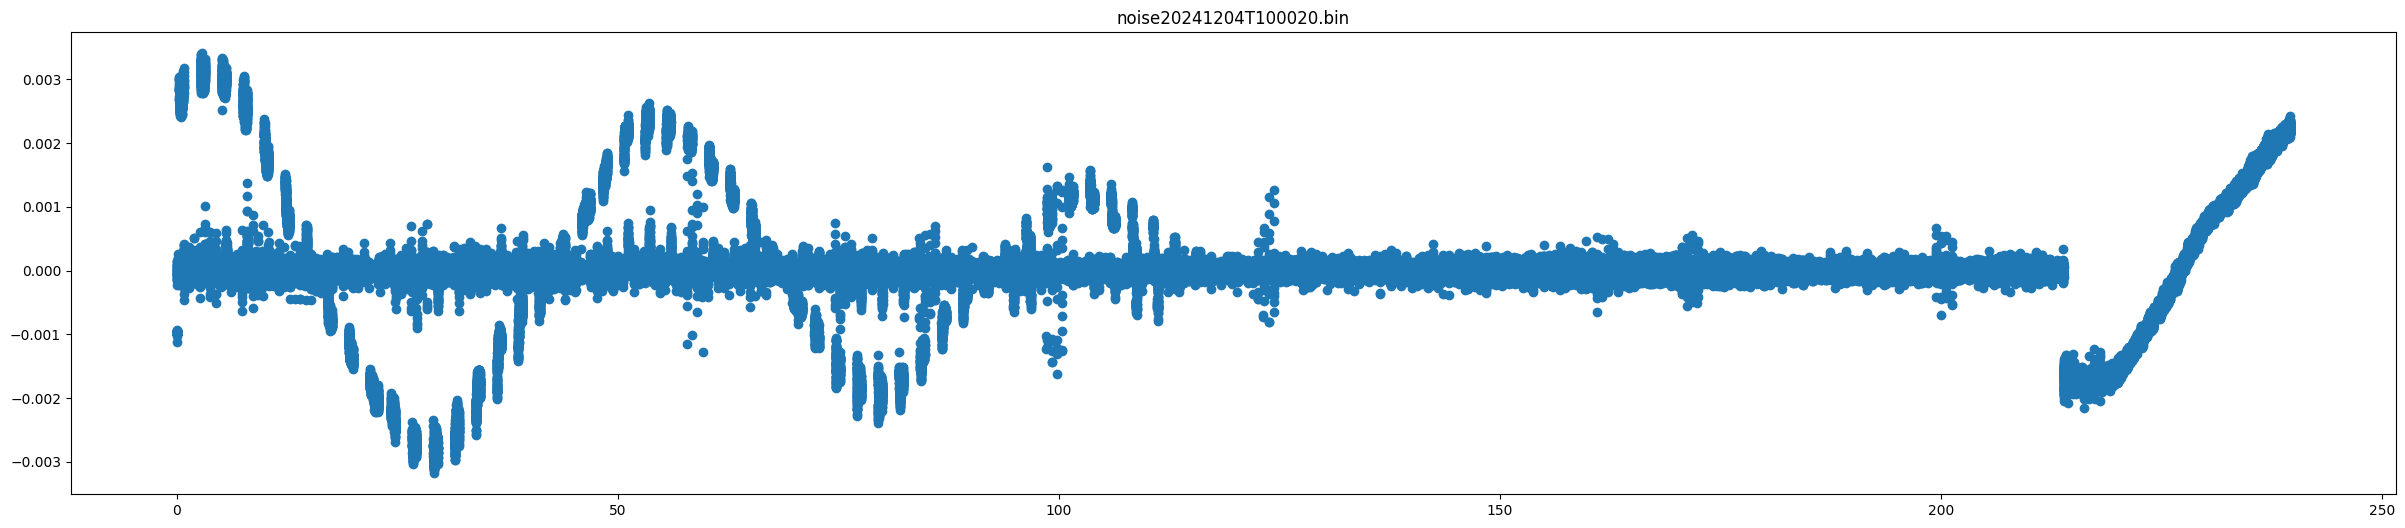

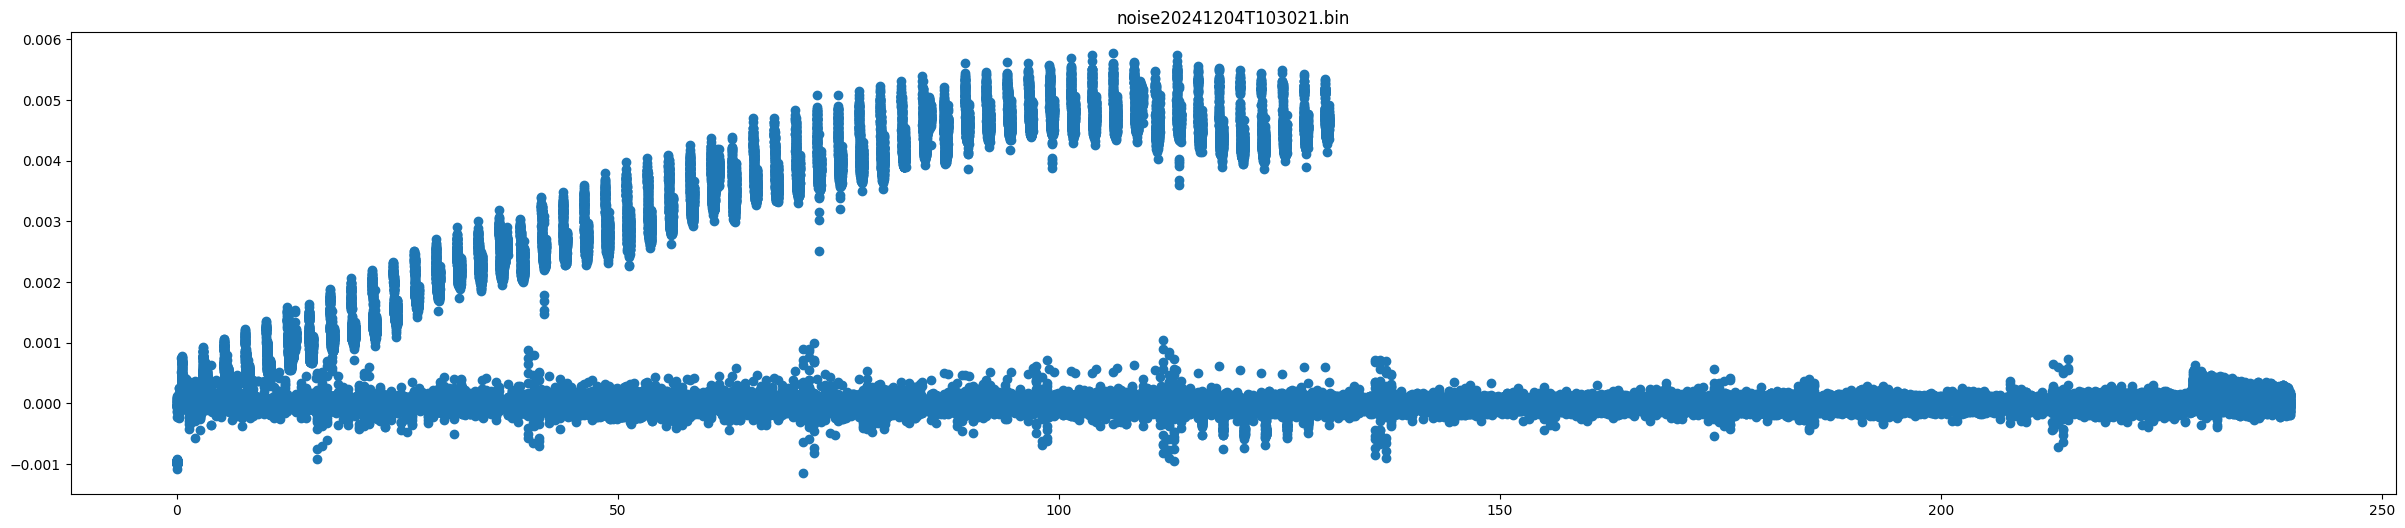

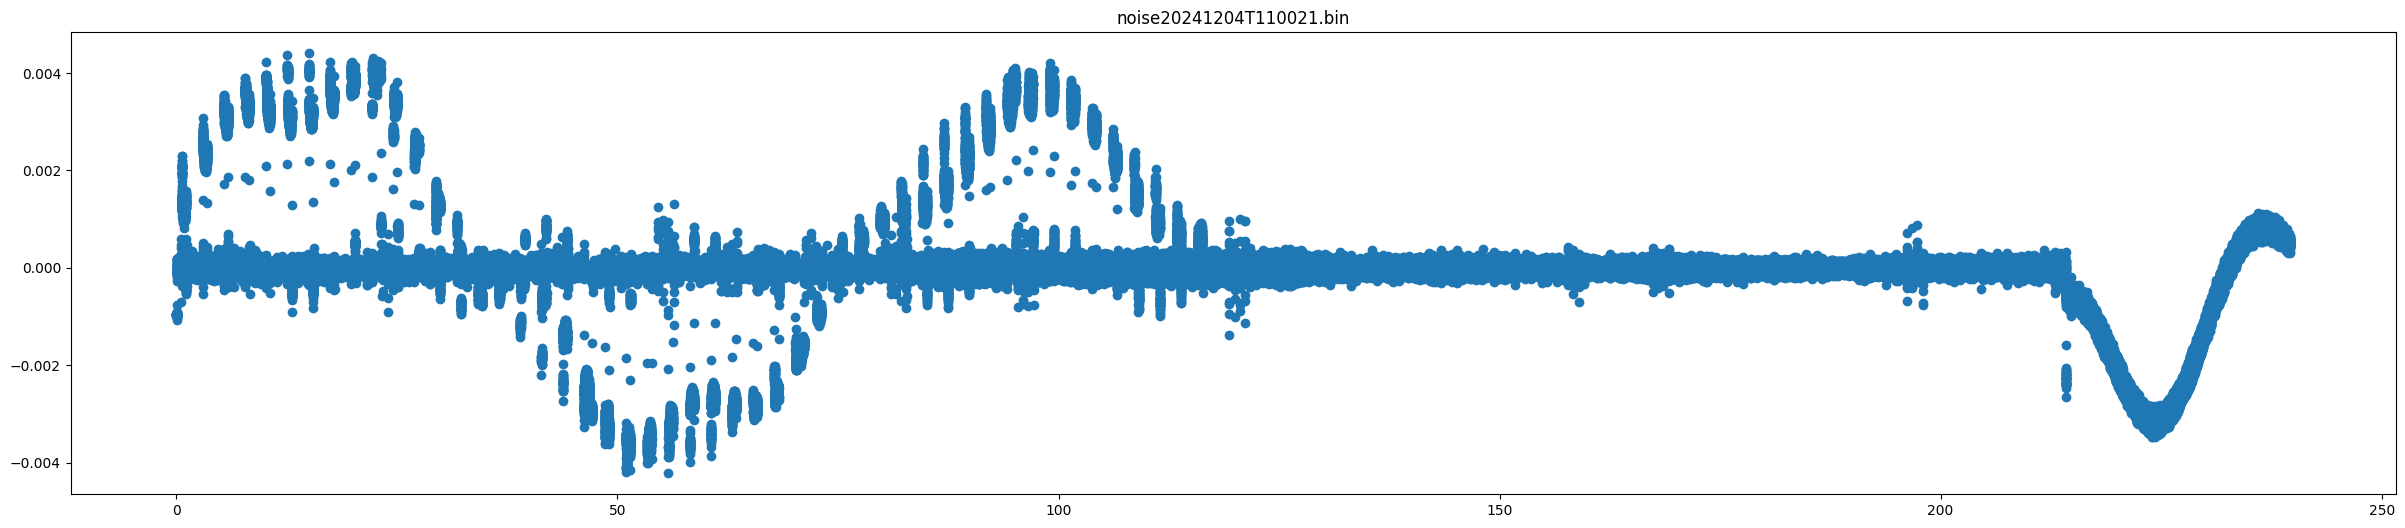

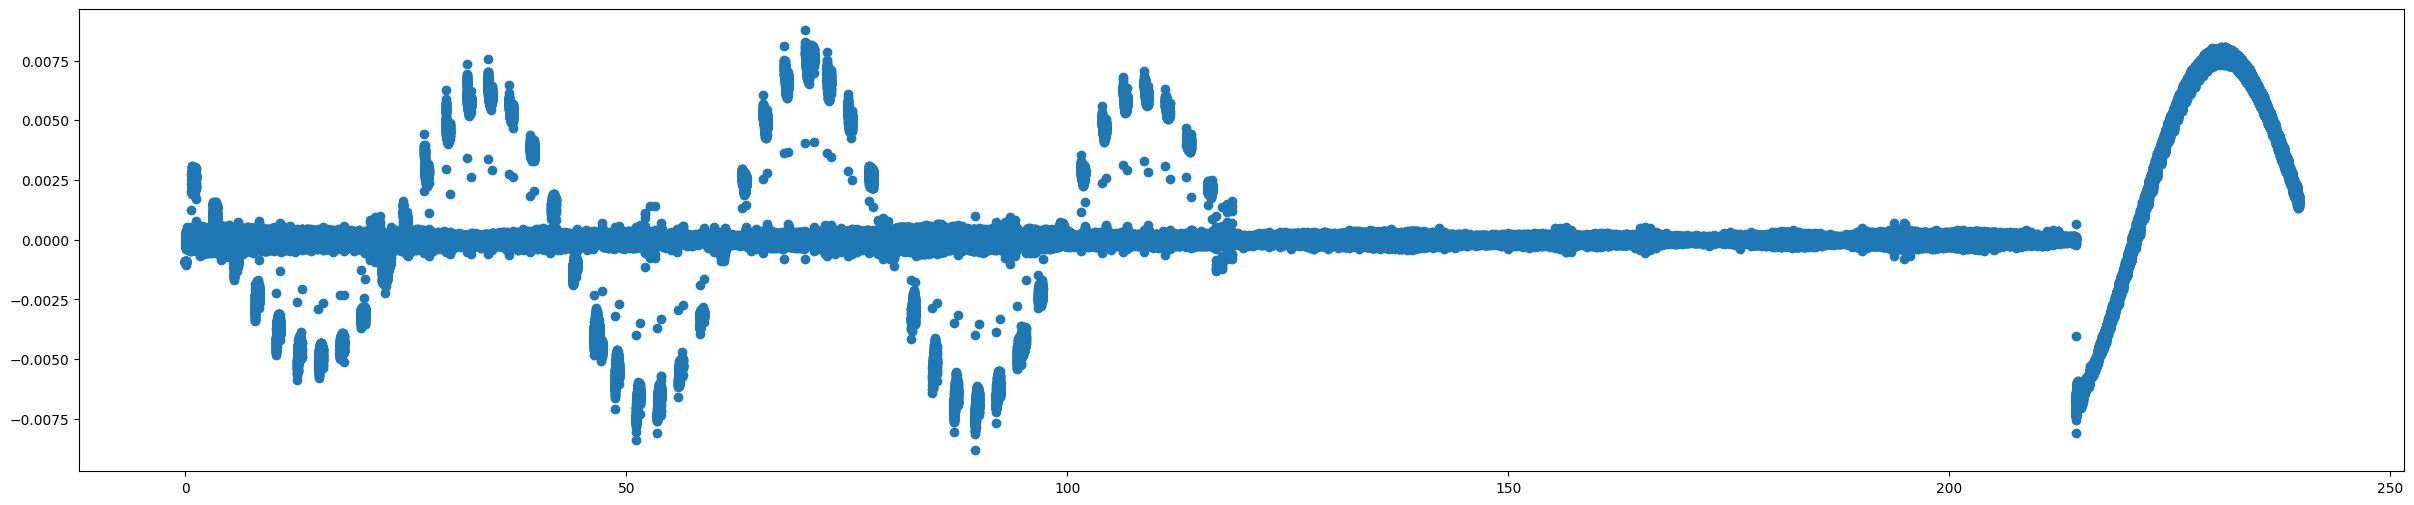

In [34]:
# data = np.fromfile(".\\data\\rwm-2024-12-04\\rwm20241204T110021.bin", dtype=np.float64)


for file in files_rwm+files_noise:
    data = np.fromfile(file, dtype=np.complex64)
    print(f'file: {file}\nlen: {len(data)}')
    time = np.arange(len(data)) / 1000

    plt.title(file.split('\\')[-1])
    plt.figure(figsize=(30, 6))
    plt.scatter(time, data)

In [75]:
file_path = '.\\data\\rwm-2024-12-04\\rwm20241204T090020.bin'

data = np.fromfile(file_path, dtype=np.complex64)
data = np.abs(data)
print(f'file: {file}\nlen: {len(data)}')
time = np.arange(len(data)) / 1000

file: .\data\rwm-2024-12-04\noise20241204T110021.bin
len: 479232


In [84]:
window = 10 * 1000# ширина окна 10 секунд

move_data = []

step = 0
time_s = 0
time_f = time_s + window

for i in range(window // 2, len(data) - window // 2):
    elem = data[i - window // 2: i + window // 2 - 1]
    move_data.append(np.average(elem))
move_time = time[window // 2: - window // 2]
        

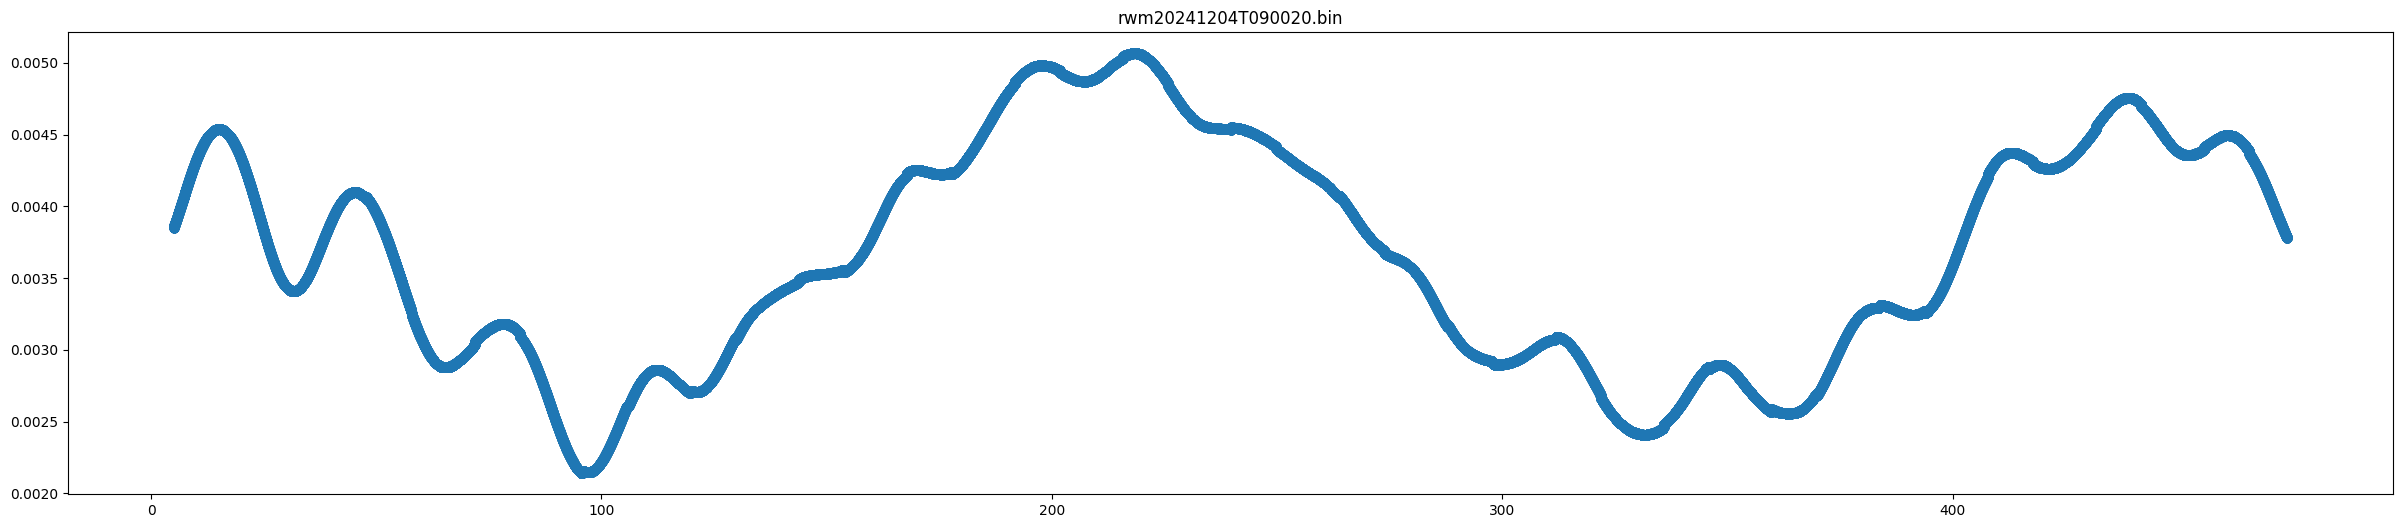

In [85]:
plt.figure(figsize=(30, 6))
plt.title(file_path.split('\\')[-1])
# plt.scatter(time, data)
plt.scatter(move_time, move_data)